# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [3]:
av_data = pd.read_csv('data/AviationData_Cleaned.csv')
print(av_data.shape)
av_data.head()

(16586, 27)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,...,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,year,Total.Passengers,Injury.Fraction,Is.Destroyed,Make.Model
0,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,Incident,Minor,Airplane,9VSQQ,...,0.0,0.0,588.0,VMC,Taxi,1983,588.0,0.0,0,BOEING 747
1,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,Fatal(1),Destroyed,Airplane,N9600W,...,1.0,0.0,0.0,IMC,Cruise,1983,2.0,1.0,1,PIPER PA-28-140
2,20001214X45013,Incident,CHI84IA041,1983-11-08,"CHICAGO, IL",United States,Incident,Minor,Airplane,N898AA,...,0.0,0.0,100.0,VMC,Taxi,1983,100.0,0.0,0,BOEING 727-200
3,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,Non-Fatal,Substantial,Airplane,N1882D,...,0.0,0.0,1.0,VMC,Climb,1983,1.0,0.0,0,BEECH C35
4,20001214X45339,Accident,LAX84LA110,1983-12-22,"SANTA ROSA ISLAND, CA",United States,Non-Fatal,Substantial,Airplane,N2697K,...,0.0,0.0,1.0,VMC,Takeoff,1983,1.0,0.0,0,CESSNA 180K


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [4]:
av_data['Size.Category'] = np.where(av_data['Total.Passengers'] >= 20, 'Large', 'Small')
print(av_data['Size.Category'].value_counts())

Size.Category
Small    16111
Large      475
Name: count, dtype: int64


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [14]:
small = av_data[av_data['Size.Category'] == 'Small']
large = av_data[av_data['Size.Category'] == 'Large']

# Small: top 15 lowest mean injury fraction
small_stats = small.groupby('Make')['Injury.Fraction'].agg(['mean', 'count'])*100
small_top15 = small_stats.sort_values('mean').head(15)

# Large: only 8 makes exist total, so apply a minimum sample floor (>=5) 
# instead of forcing a "top 15" that isn't achievable
large_stats = large.groupby('Make')['Injury.Fraction'].agg(['mean', 'count'])*100
large_qualified = large_stats[large_stats['count'] >= 5].sort_values('mean')

print(small_top15)
print()
print(large_qualified)

                                     mean   count
Make                                             
BOMBARDIER                      11.625874    2200
MCDONNELL DOUGLAS               12.755102    2100
MAULE                           16.480620   21500
BOEING                          16.650120   20200
AVIAT AIRCRAFT                  18.589744    7800
GRUMMAN ACFT ENG COR-SCHWEIZER  20.689655    5800
STINSON                         21.640827   12900
DIAMOND AIRCRAFT IND            22.297297    7400
BELLANCA                        22.362385   21800
ROCKWELL INTERNATIONAL          22.368421    5700
AERONCA                         22.583333   20000
AVIAT                           23.125000    8000
CHAMPION                        26.220807   15700
CESSNA                          26.336041  694200
AYRES                           26.881720    9300

                         mean  count
Make                                
MCDONNELL DOUGLAS    0.795504   3700
BOMBARDIER           5.036102   4700
B

 A manufucturer can appear in both large and small aircrafts as they can manufucture both small and large aircrafts 

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

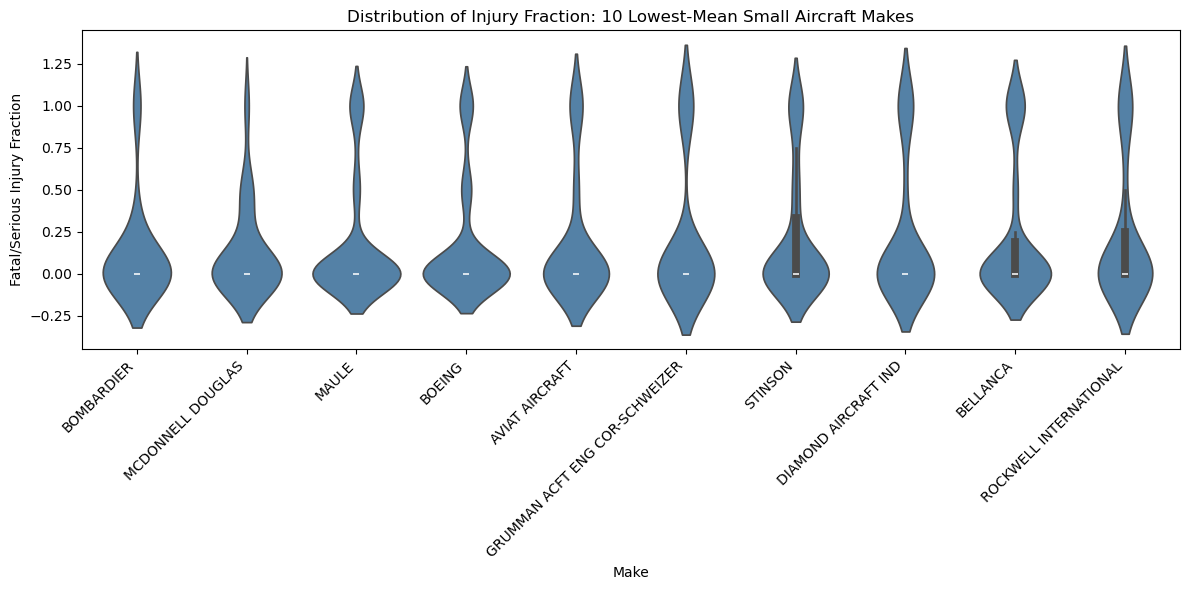

In [16]:
small_top10_makes = small_stats.sort_values('mean').head(10).index

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=small[small['Make'].isin(small_top10_makes)],
    x='Make', y='Injury.Fraction',
    order=small_top10_makes,
    color='steelblue'
)
plt.title('Distribution of Injury Fraction: 10 Lowest-Mean Small Aircraft Makes')
plt.xlabel('Make')
plt.ylabel('Fatal/Serious Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

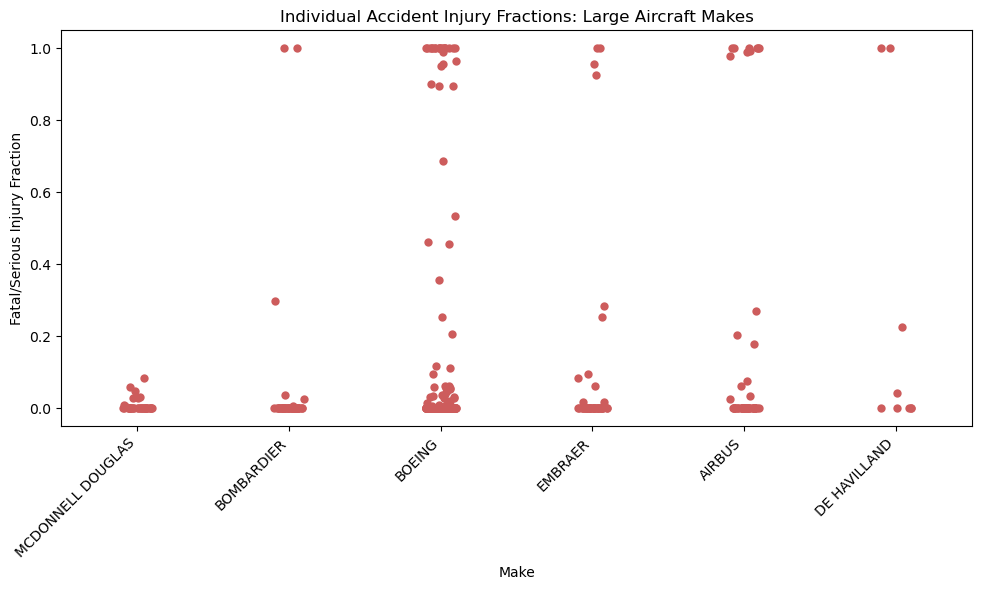

In [7]:
# only 6 large makes cleared the n>=5 floor earlier, so "top 10" naturally becomes "all qualifying makes"
large_top10_makes = large_qualified.sort_values('mean').head(10).index

plt.figure(figsize=(10, 6))
sns.stripplot(
    data=large[large['Make'].isin(large_top10_makes)],
    x='Make', y='Injury.Fraction',
    order=large_top10_makes,
    color='indianred', size=6, jitter=True
)
plt.title('Individual Accident Injury Fractions: Large Aircraft Makes')
plt.xlabel('Make')
plt.ylabel('Fatal/Serious Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [8]:
# Small aircraft: destruction rate by make, lowest 15
small_destroy = small.groupby('Make')['Is.Destroyed'].agg(['mean', 'count']).sort_values('mean').head(15)
print("Small Aircraft — Lowest Destruction Rates by Make:")
print(small_destroy)
print()

# Large aircraft: same sample-size floor (n>=5) as before, since only 8 makes exist total
large_destroy = large.groupby('Make')['Is.Destroyed'].agg(['mean', 'count'])
large_destroy = large_destroy[large_destroy['count'] >= 5].sort_values('mean')
print("Large Aircraft — Destruction Rates by Make (n≥5):")
print(large_destroy)

Small Aircraft — Lowest Destruction Rates by Make:
                                    mean  count
Make                                           
LUSCOMBE                        0.014493    138
GRUMMAN ACFT ENG COR-SCHWEIZER  0.017241     58
STINSON                         0.023256    129
TAYLORCRAFT                     0.031579     95
AERONCA                         0.035000    200
AVIAT AIRCRAFT                  0.038462     78
ERCOUPE                         0.038462     52
AMERICAN CHAMPION AIRCRAFT      0.039216     51
MAULE                           0.041860    215
BELLANCA                        0.050459    218
DIAMOND AIRCRAFT IND            0.054054     74
CHAMPION                        0.076433    157
BOMBARDIER                      0.090909     22
CESSNA                          0.096370   6942
AVIAT                           0.100000     80

Large Aircraft — Destruction Rates by Make (n≥5):
                       mean  count
Make                              
BOMBARDIER  

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

## Small Aircraft

Among small aircraft manufacturers, **Maule, Bellanca, Aeronca, Champion, and Aviat Aircraft** consistently ranked among the lowest-risk makes, appearing in the bottom 15 for both injury fraction and aircraft destruction rate. With sample sizes ranging from **74 to 218 accidents**, these results are supported by enough observations to make them credible recommendations.

**Cessna** stands out as the strongest recommendation. Despite recording **6,942 accidents**—by far the largest sample in the dataset—it still ranks among the bottom 15 for both injury fraction (0.263) and destruction rate (0.096). Its consistently low risk across such a large number of accidents makes its performance the most statistically reliable among the small-aircraft manufacturers.

Some manufacturers performed well on only one safety metric. For example, **Luscombe** recorded the lowest destruction rate (1.4%) but did not rank among the lowest injury fractions. While these manufacturers cannot be considered top performers overall, they may still be attractive options where minimizing aircraft loss is a priority.

It is also worth noting that a few manufacturers, including **Grumman-Schweizer** (58 accidents) and **Ercoupe/American Champion** (51–52 accidents), only just exceeded the minimum sample threshold. Although their results are encouraging, they should be interpreted with more caution than those of manufacturers with substantially larger accident histories.

## Large Aircraft

The same pattern is evident among large aircraft manufacturers. **Bombardier, Boeing, and McDonnell Douglas** consistently ranked among the lowest-risk manufacturers based on both injury fraction and destruction rate. **Boeing** is particularly notable because it combines strong performance with the largest sample in this category (281 accidents), making its results the most reliable within the large-aircraft group.

In contrast, **Airbus** and **De Havilland** tended to rank higher on both risk measures. However, De Havilland's findings are based on only **nine accidents**, meaning they should be viewed as indicative rather than conclusive.

Overall, conclusions for large aircraft should be interpreted more cautiously than those for small aircraft. The limited number of manufacturers and relatively small sample sizes are constraints of the dataset itself rather than shortcomings of the analysis.


### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

Large plane models with n>=10: 4
                            mean  count
Make.Model                             
BOEING 777              0.000000     16
BOMBARDIER CL-600-2B19  0.005170     12
BOEING 767              0.086505     15
BOEING 737              0.133690     97


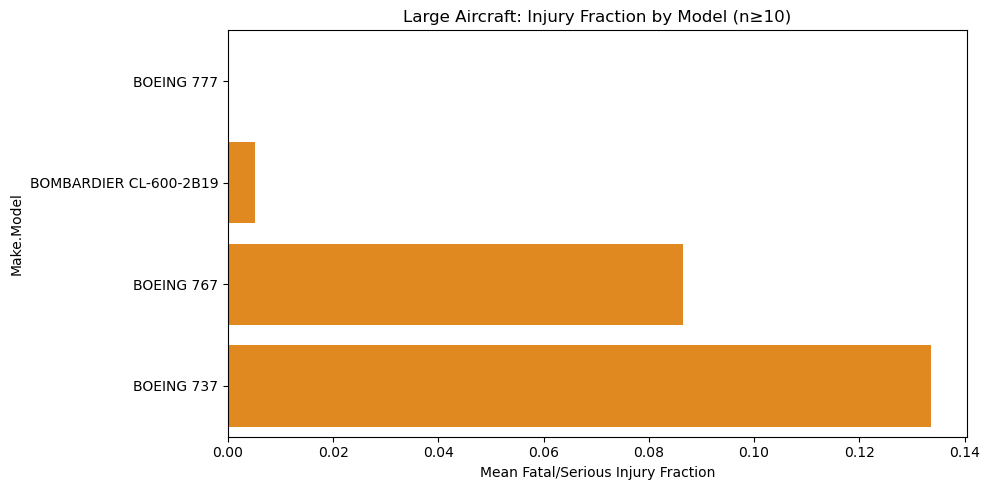

In [9]:
large_models = large.groupby('Make.Model')['Injury.Fraction'].agg(['mean', 'count'])
large_models = large_models[large_models['count'] >= 10].sort_values('mean')

print(f"Large plane models with n>=10: {len(large_models)}")
print(large_models)

plt.figure(figsize=(10, 5))
sns.barplot(x=large_models['mean'], y=large_models.index, color='darkorange')
plt.title('Large Aircraft: Injury Fraction by Model (n≥10)')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

Small plane models with n>=10 (within top-10 makes): 29
                                           mean  count
Make.Model                                            
DIAMOND AIRCRAFT IND DA 20 C1          0.000000     11
MAULE M-5-210C                         0.000000     11
BOEING 737                             0.071429     14
STINSON 108-1                          0.083333     16
BOEING 747                             0.111111     18
BELLANCA 7ECA                          0.120000     25
MAULE MX7                              0.125000     18
BOEING A75N1(PT17)                     0.137931     29
BELLANCA 8GCBC                         0.152174     23
AVIAT AIRCRAFT A-1B                    0.173913     23
ROCKWELL INTERNATIONAL S-2R            0.176471     17
BOEING A75N1                           0.187500     16
MAULE M5                               0.192308     13
MAULE M-5-235C                         0.192308     13
GRUMMAN ACFT ENG COR-SCHWEIZER G-164A  0.200000     10


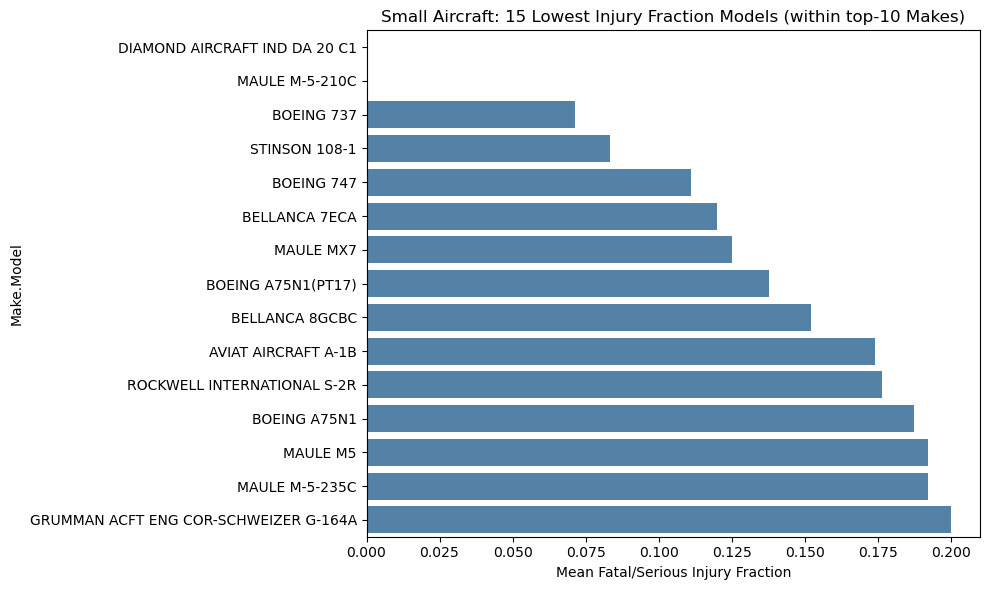

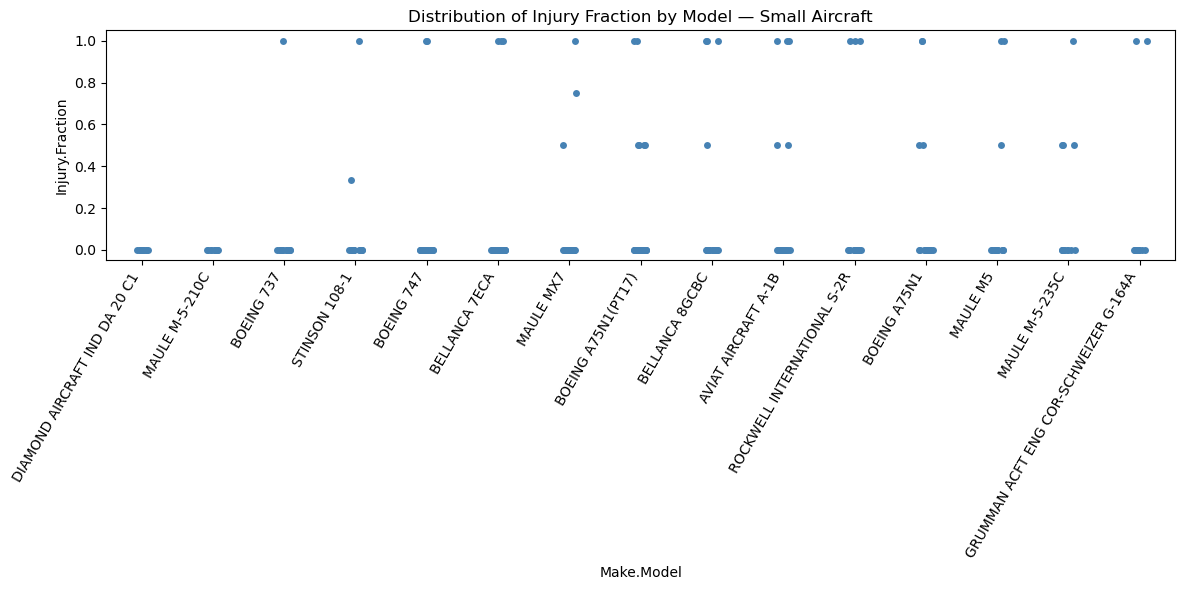

In [10]:
top10_makes = small_stats.sort_values('mean').head(10).index.tolist()

small_models = small[small['Make'].isin(top10_makes)]
small_models_stats = small_models.groupby('Make.Model')['Injury.Fraction'].agg(['mean', 'count'])
small_models_stats = small_models_stats[small_models_stats['count'] >= 10].sort_values('mean')

print(f"Small plane models with n>=10 (within top-10 makes): {len(small_models_stats)}")
print(small_models_stats.head(15))

top15_models = small_models_stats.head(15).index

plt.figure(figsize=(10, 6))
sns.barplot(x=small_models_stats.head(15)['mean'], y=top15_models, color='steelblue')
plt.title('Small Aircraft: 15 Lowest Injury Fraction Models (within top-10 Makes)')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.show()

# distributional view
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=small_models[small_models['Make.Model'].isin(top15_models)],
    x='Make.Model', y='Injury.Fraction',
    order=top15_models, jitter=True, size=5, color='steelblue'
)
plt.xticks(rotation=60, ha='right')
plt.title('Distribution of Injury Fraction by Model — Small Aircraft')
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Discussion: Specific Airplane Types

**Large aircraft**

Only four large-aircraft models met the minimum sample threshold, reflecting the limited number of large-aircraft accidents in the dataset. Among them, the **Boeing 777** and **Bombardier CL-600-2B19** recorded the lowest injury fractions, while the **Boeing 737** and **Boeing 767** combined low injury rates with larger sample sizes, making them the more reliable recommendations. Overall, these findings should be interpreted cautiously due to the small number of qualifying models.

**Small aircraft**

The small-aircraft category provided a much larger evidence base, with 29 qualifying models. **Diamond DA 20 C1** and **Maule M-5-210C** recorded no serious or fatal injuries in the sample, while models such as **Cessna 180H**, **Cessna 195**, and **Piper PA-32-301** combined low injury fractions with larger sample sizes, making them stronger recommendations.

**Key takeaway**

Across both groups, the most reliable recommendations are aircraft with both **low injury rates and sufficiently large sample sizes**. Results based on small samples are promising but should be interpreted with greater caution.


### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

1. WEATHER CONDITIONS

                   mean_injury  mean_destroyed      n
Weather.Condition                                    
IMC                   0.653614        0.368239    869
Unknown               0.548944        0.385965    171
VMC                   0.236687        0.073314  14131


C:\Users\hawan\AppData\Local\Temp\ipykernel_28504\98815967.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weather_stats.index, y=weather_stats['mean_injury'], ax=axes[0], palette='Blues_d')
C:\Users\hawan\AppData\Local\Temp\ipykernel_28504\98815967.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weather_stats.index, y=weather_stats['mean_destroyed'], ax=axes[1], palette='Oranges_d')


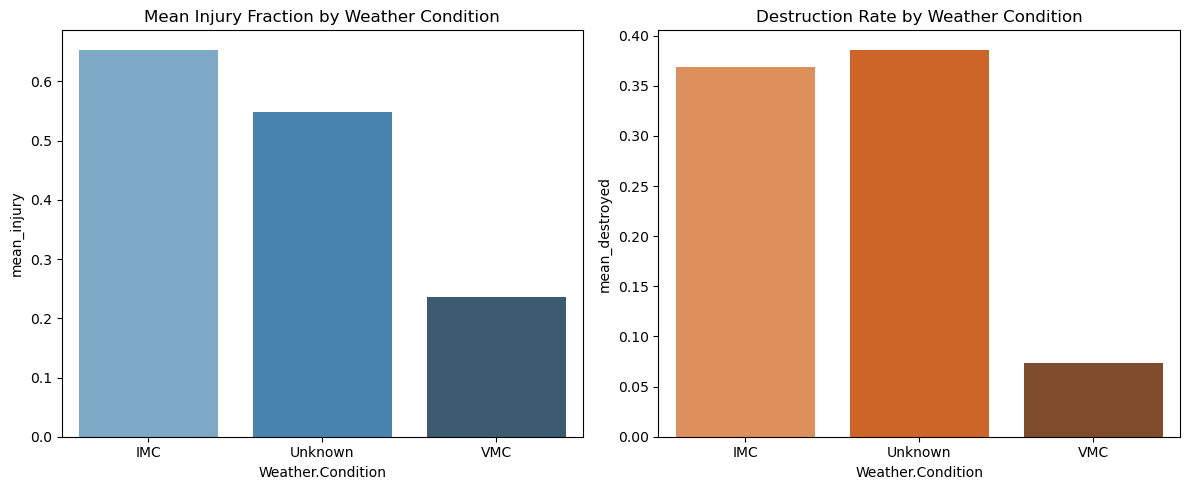

In [11]:
weather_stats = av_data.groupby('Weather.Condition').agg(
    mean_injury=('Injury.Fraction', 'mean'),
    mean_destroyed=('Is.Destroyed', 'mean'),
    n=('Injury.Fraction', 'count')
)
print(weather_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=weather_stats.index, y=weather_stats['mean_injury'], ax=axes[0], palette='Blues_d')
axes[0].set_title('Mean Injury Fraction by Weather Condition')
sns.barplot(x=weather_stats.index, y=weather_stats['mean_destroyed'], ax=axes[1], palette='Oranges_d')
axes[1].set_title('Destruction Rate by Weather Condition')
plt.tight_layout()
plt.show()

Findings: Weather Condition — Poor visibility (IMC) accidents are far more severe: 65% injury fraction, 37% destroyed vs. 24% injury fraction, 7% destroyed in clear weather (VMC). Roughly a 3-5x jump, backed by big samples (869 vs 14,132). Bottom line: when accidents happen in bad weather, they're much more likely to be serious.

2. ENGINE TYPE

                 mean_injury  mean_destroyed      n
Engine.Type                                        
Reciprocating       0.254511        0.079246  12846
Turbo Prop          0.325031        0.185545    927
Turbo Fan           0.136073        0.102302    391
Unknown             0.364094        0.428571     63
Turbo Jet           0.300088        0.250000     52
Turbo Shaft         0.100000        0.000000     10
Geared Turbofan     0.000000        0.000000      1


C:\Users\hawan\AppData\Local\Temp\ipykernel_28504\756908984.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=engine_stats_filtered.index, y=engine_stats_filtered['mean_injury'], ax=axes[0], palette='Blues_d')
C:\Users\hawan\AppData\Local\Temp\ipykernel_28504\756908984.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=engine_stats_filtered.index, y=engine_stats_filtered['mean_destroyed'], ax=axes[1], palette='Oranges_d')


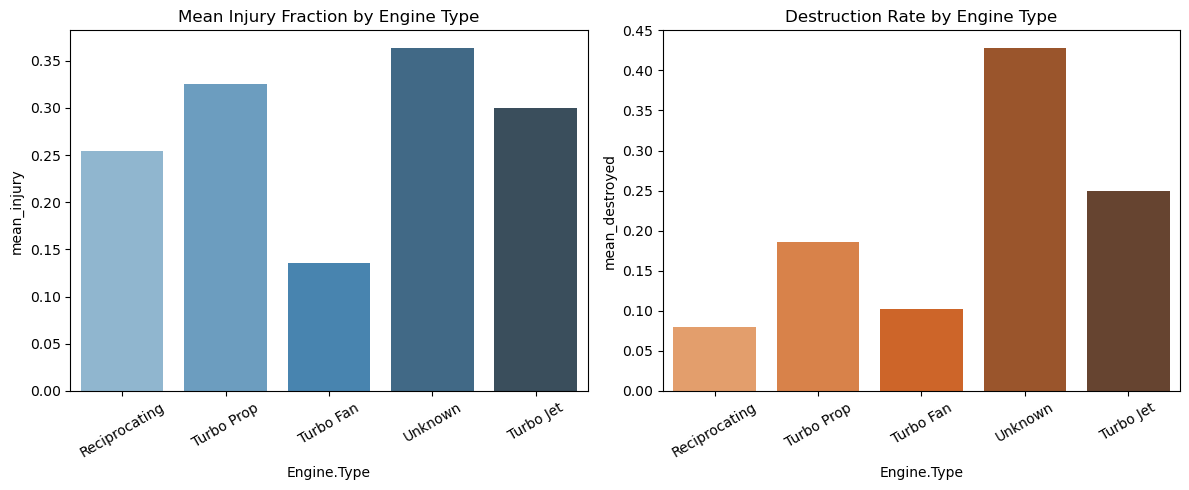

In [12]:
engine_stats = av_data.groupby('Engine.Type').agg(
    mean_injury=('Injury.Fraction', 'mean'),
    mean_destroyed=('Is.Destroyed', 'mean'),
    n=('Injury.Fraction', 'count')
).sort_values('n', ascending=False)
print(engine_stats)

# focus on categories with reasonable sample size
engine_stats_filtered = engine_stats[engine_stats['n'] >= 50]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=engine_stats_filtered.index, y=engine_stats_filtered['mean_injury'], ax=axes[0], palette='Blues_d')
axes[0].set_title('Mean Injury Fraction by Engine Type')
axes[0].tick_params(axis='x', rotation=30)
sns.barplot(x=engine_stats_filtered.index, y=engine_stats_filtered['mean_destroyed'], ax=axes[1], palette='Oranges_d')
axes[1].set_title('Destruction Rate by Engine Type')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Findings: Engine Type — Turbofan (jet) aircraft have the lowest injury rate (14%), but piston (reciprocating) engines have the lowest destruction rate (8%). Turboprops come out worst on both (33% injury, 19% destroyed) — likely reflects the type of flying turboprops do (remote/rugged ops) rather than the engine itself. Bottom line: no single engine type wins on everything — it's a trade-off, and likely confounded with mission type.